In [1]:
!pip install squidpy
!pip install cellcharter
!pip install lightning
!pip install scvi-colab

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.3/161.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
# Restart session
exit()

In [1]:
# Install SCVI
import scvi_colab

scvi_colab.install()
!pip install scvi-tools

INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                                           


In [2]:
 !pip uninstall scipy && pip install scipy

Found existing installation: scipy 1.14.1
Uninstalling scipy-1.14.1:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/scipy-1.14.1.dist-info/*
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libquadmath-96973f99.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libscipy_openblas-c128ec02.so
    /usr/local/lib/python3.11/dist-packages/scipy/*
Proceed (Y/n)? Y
  Successfully uninstalled scipy-1.14.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 23.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source

In [3]:
!pip uninstall seaborn && pip install seaborn

Found existing installation: seaborn 0.13.2
Uninstalling seaborn-0.13.2:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/seaborn-0.13.2.dist-info/*
    /usr/local/lib/python3.11/dist-packages/seaborn/*
Proceed (Y/n)? Y
  Successfully uninstalled seaborn-0.13.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.3 MB/s eta 0:00:00


In [1]:
# Restart session
exit()

In [20]:
import gc
import scvi
import scipy
import torch
import random
import anndata

import numpy as np
import pandas as pd
import seaborn as sns
import squidpy as sq
import lightning as pl
import cellcharter as cc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from lightning.pytorch import seed_everything
from scipy.sparse.csgraph import connected_components

In [2]:
print("Last run with scvi-tools version:", scvi.__version__)

Last run with scvi-tools version: 1.3.1.post1


In [3]:
def set_seed(seed: int = 42) -> None:
    """ Function setting the seed.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    pl.seed_everything(seed)
    scvi.settings.seed = seed
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


In [4]:
from google.colab import drive
drive.mount('/content/drive')
TRAIN_ANNDATA_PATH = '/content/drive/MyDrive/data/train_adata.h5ad'

sns.set_theme()
plt.rcParams['figure.figsize'] = (12, 9)

train_anndata = anndata.read_h5ad(TRAIN_ANNDATA_PATH)
print(train_anndata)

Mounted at /content/drive
AnnData object with n_obs × n_vars = 253433 × 40
    obs: 'image', 'sample_id', 'ObjectNumber', 'Pos_X', 'Pos_Y', 'area', 'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px', 'height_px', 'acquisition_id', 'SlideId', 'Study', 'Box.Description', 'Position', 'SampleId', 'Indication', 'BatchId', 'SubBatchId', 'ROI', 'ROIonSlide', 'includeImage', 'flag_no_cells', 'flag_no_ROI', 'flag_total_area', 'flag_percent_covered', 'small_cell', 'celltypes', 'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos', 'tumor_patches', 'distToCells', 'CD20_patches', 'Batch', 'cell_labels', 'classifier'
    var: 'channel', 'use_channel', 'marker'
    layers: 'exprs'


In [5]:
# Standardisation for PCA on cells' marker expression
expressions = train_anndata.layers['exprs']
total_counts = expressions.sum(axis=1, keepdims=True)
norm_exprs = (expressions / total_counts) * 1e6
norm_exprs = np.log1p(norm_exprs)
train_anndata.layers['normalised_exprs'] = norm_exprs

# PCA explaining 95% of variance
pca = PCA(n_components=0.95, svd_solver='full')
pca_exprs = pca.fit_transform(norm_exprs)
print(f"PCA: Number of components = {pca_exprs.shape[1]}, Explained variance = {pca.explained_variance_ratio_.sum():.2f}")

# Store in obsm
train_anndata.obsm['X_PCA'] = pca_exprs

PCA: Number of components = 25, Explained variance = 0.95


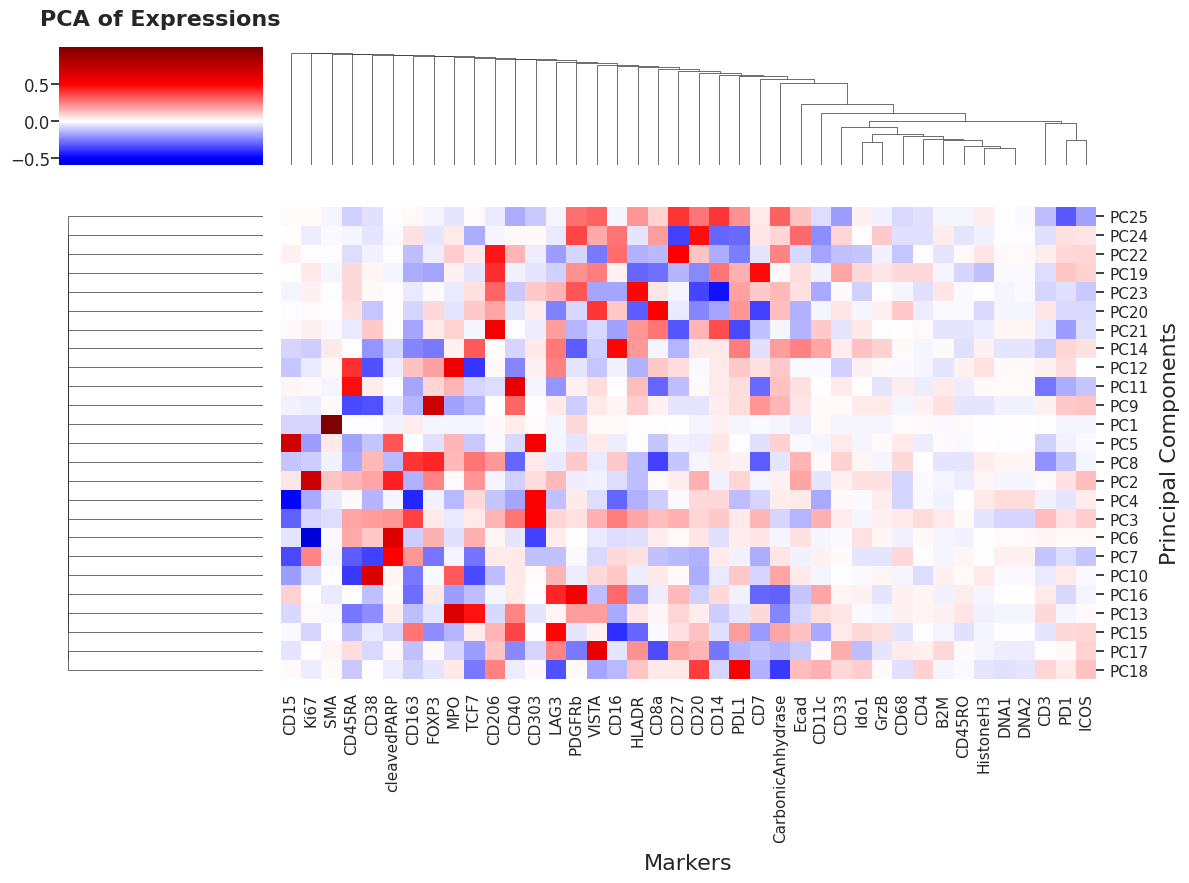

In [6]:
def plot_clustermap(data: pd.DataFrame,
                    x_labels: pd.DataFrame,
                    shape: int,
                    title: str) -> None:
    """ Helper function for plotting clustermap.
    """
    plot = sns.clustermap(
        data,
        cmap='seismic',
        center=0.0,
        xticklabels=x_labels,
        yticklabels=[f"PC{idx+1}" for idx in range(shape)],
        figsize=plt.rcParams['figure.figsize'],
    )

    # Improved layout for the plot
    cbar = plot.ax_heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12,
                        pad=0.10,
                        labelleft=True,
                        labelright=False,
                        left=True,
                        right=False
    )

    plot.ax_heatmap.set_xlabel('Markers', fontsize=16, labelpad=8)
    plot.ax_heatmap.set_ylabel('Principal Components', fontsize=16, labelpad=8)
    plt.title(title, fontsize=16, pad=16, loc='center', weight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()


plot_clustermap(pca.components_,
                train_anndata.var['marker'],
                pca_exprs.shape[1],
                'PCA of Expressions'
)

# Cellcharter again

In [7]:
def plot_heatmap(data: pd.DataFrame,
                 title: str,
                 fmt: str,
                 figsize: tuple = None,
                 xlabel: str = "Cell Types") -> None:
    """ Helper function for plotting heatmap.
    """
    if figsize:
        plt.figure(figsize=figsize)
        sns.heatmap(data, annot=True, fmt=fmt, cmap=sns.cubehelix_palette(as_cmap=True))
    else:
        plt.figure(figsize=plt.rcParams['figure.figsize'])
        sns.heatmap(data, annot=True, fmt=fmt, cmap="crest")

    plt.title(title, weight='bold', fontsize=20, pad=12)
    plt.xlabel(xlabel, fontsize=16, labelpad=8)
    plt.ylabel("Clusters", fontsize=16, labelpad=8)
    plt.tight_layout()
    plt.show()
    plt.close()

In [10]:
train_anndata.obsm['spatial'] = train_anndata.obs[['Pos_X', 'Pos_Y']].values

sq.gr.spatial_neighbors(
    train_anndata,
    library_key='sample_id',
    coord_type='generic',
    delaunay=True,
    spatial_key='spatial',
    percentile=99,
)

In [ ]:
cc.gr.aggregate_neighbors(
    train_anndata,
    n_layers=3,
    use_rep='X_PCA',
    out_key='X_cellcharter',
    sample_key='sample_id'
)

  0%|          | 0/132 [00:00<?, ?it/s]

In [13]:
# Defining params for AutoK model to find best candidate for the number of clusters
n_clusters = range(2, 32)
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'

model_params = {
        'random_state': 42,
        'trainer_params': {
            'accelerator': accelerator,
            'enable_progress_bar': False
        },
}

In [ ]:
model = cc.tl.ClusterAutoK(n_clusters=n_clusters,
                           model_class=cc.tl.GaussianMixture,
                           model_params=model_params,
                           max_runs=16
)

# Change to float32 for compatibility of numpy and torch calculations
train_anndata.obsm["X_cellcharter"] = train_anndata.obsm["X_cellcharter"].astype(np.float32)

# Taking every 10th example to expedite calculations
model.fit(train_anndata[::10], use_rep='X_cellcharter')

Iteration 1/16


  0%|          | 0/30 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 2/16


  0%|          | 0/30 [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 8/16


  0%|          | 0/30 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Convergence with a change in stability of 0.00904636275202538 reached after 8 iterations


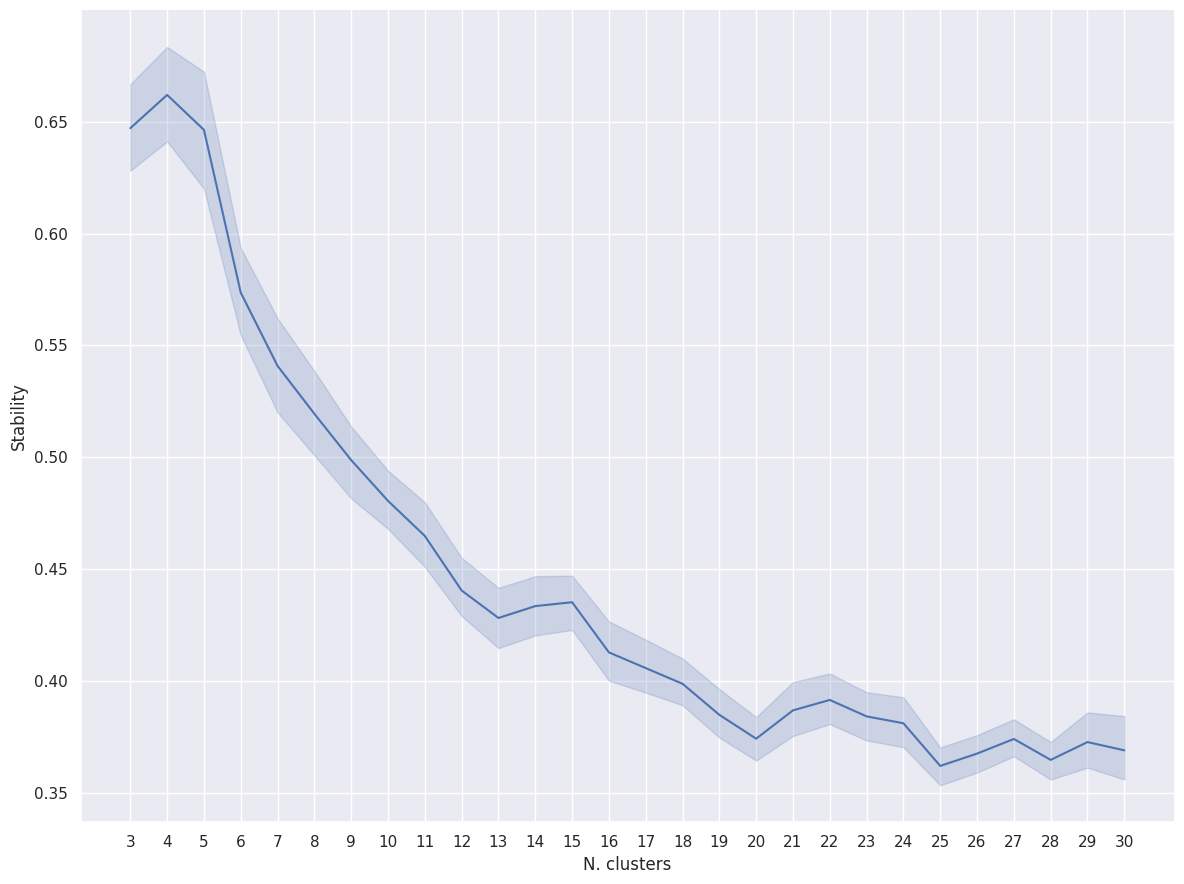

In [ ]:
# Choose the best number of clusters with peaks of stability
cc.pl.autok_stability(model)
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
best_cluster = model.best_k
print(f"In our case, {best_cluster} is the best candidate!")
train_anndata.obs['cluster_cellcharter'] = model.predict(train_anndata, use_rep='X_cellcharter', k=best_cluster)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In our case, 4 is the best candidate!


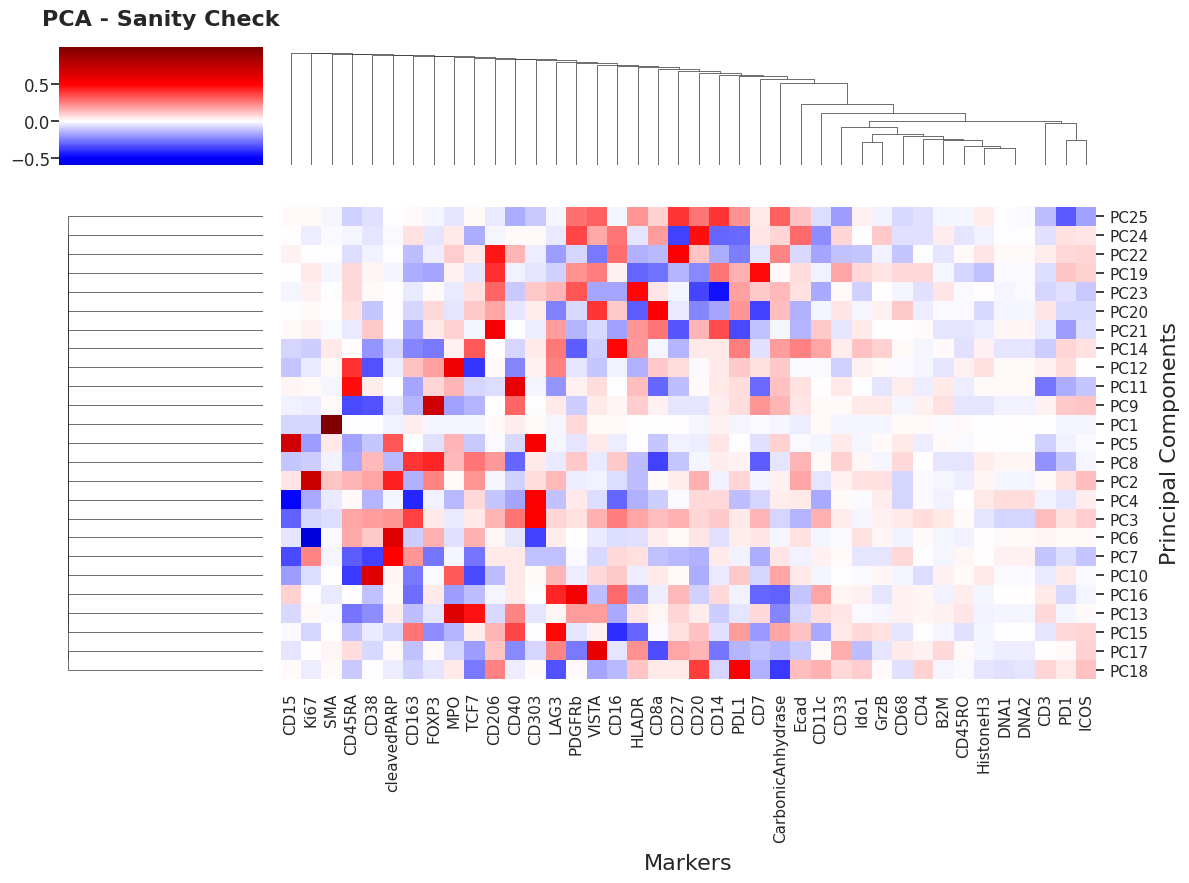

In [ ]:
# PCA
cluster_pca_model = PCA(n_components=0.95, svd_solver='full')
cluster_pca_exprs = cluster_pca_model.fit_transform(train_anndata.layers['normalised_exprs'])

plot_clustermap(cluster_pca_model.components_,
                train_anndata.var['marker'],
                cluster_pca_exprs.shape[1],
                'PCA - Sanity Check'
)

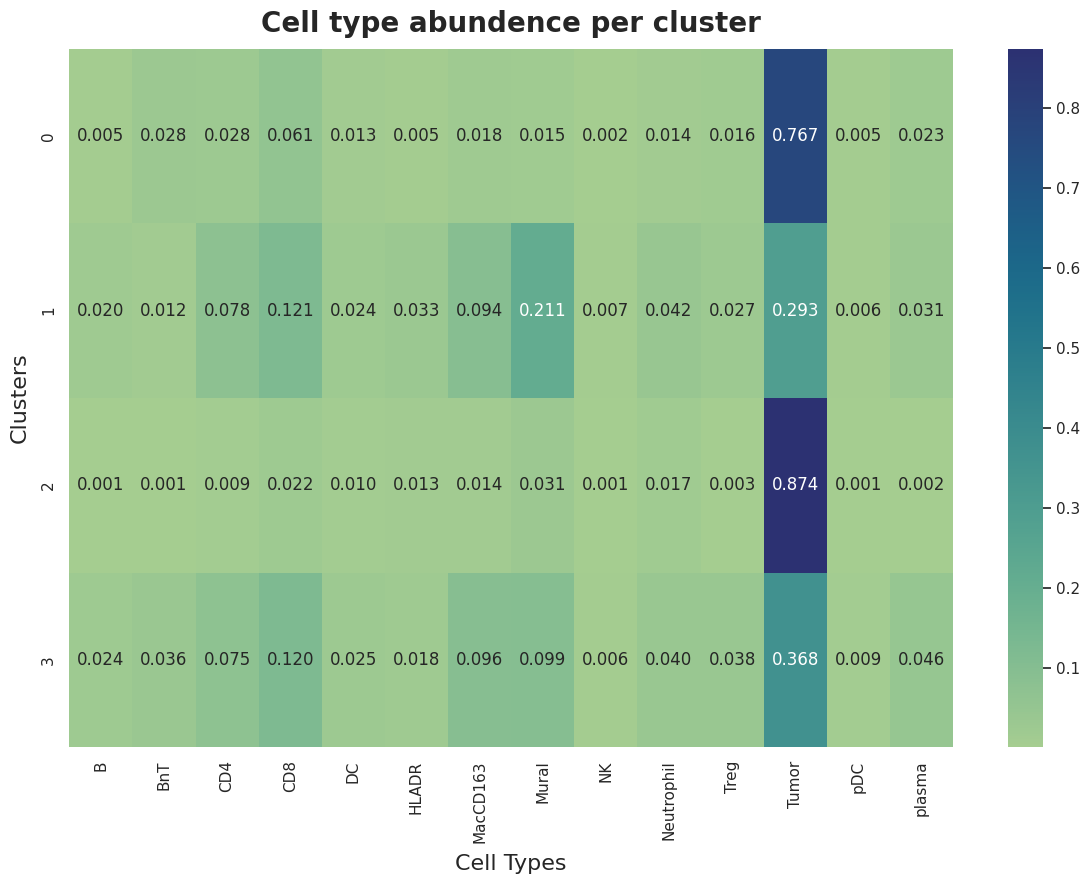

In [ ]:
# Cell type abundance
cell_type_abundance = train_anndata.obs.groupby('cluster_cellcharter', observed=True)['celltypes']\
                      .value_counts(normalize=True).unstack()
plot_heatmap(cell_type_abundance, "Cell type abundence per cluster", ".3f")

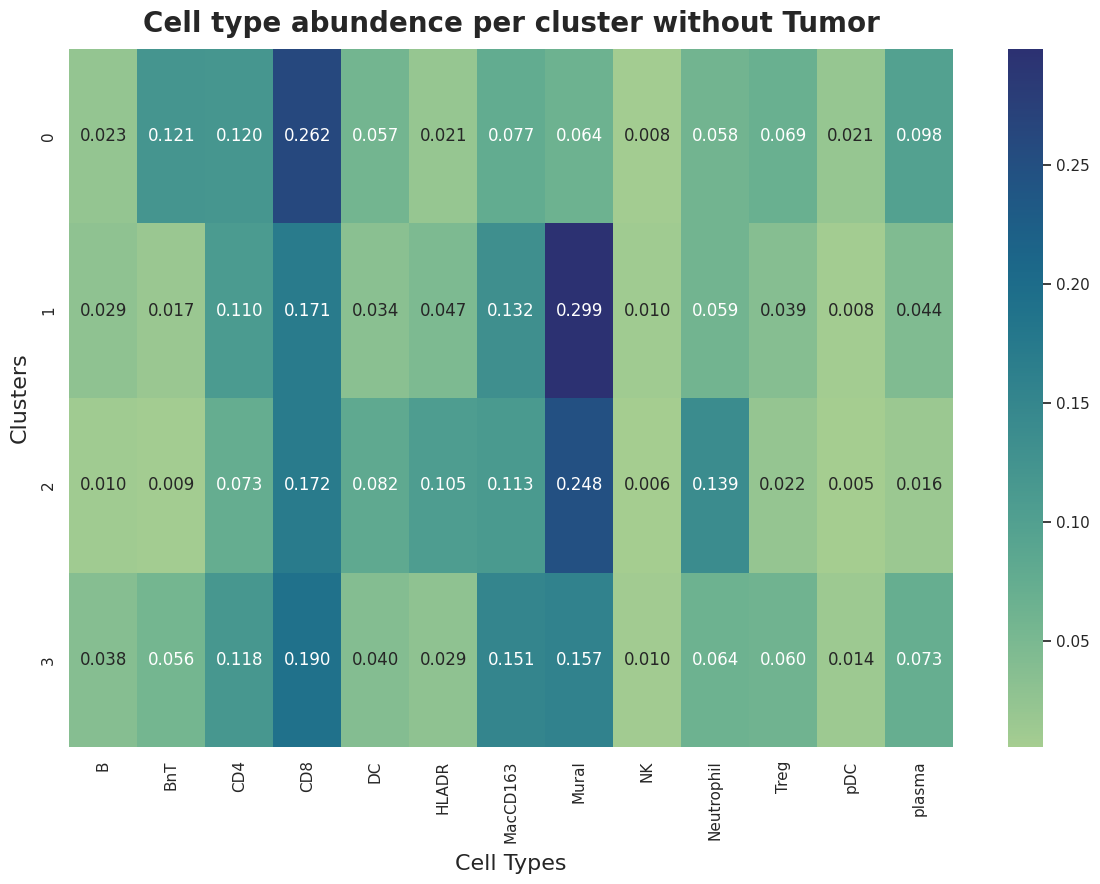

In [ ]:
# Cell type abundance without Tumor
cell_type_abundance = train_anndata.obs.groupby('cluster_cellcharter', observed=True)['celltypes']\
                      .value_counts().unstack()
cell_type_abundance.drop(columns=['Tumor'], inplace=True)
cell_type_abundance = cell_type_abundance.div(cell_type_abundance.sum(axis=1), axis=0)
plot_heatmap(cell_type_abundance, "Cell type abundence per cluster without Tumor", ".3f")

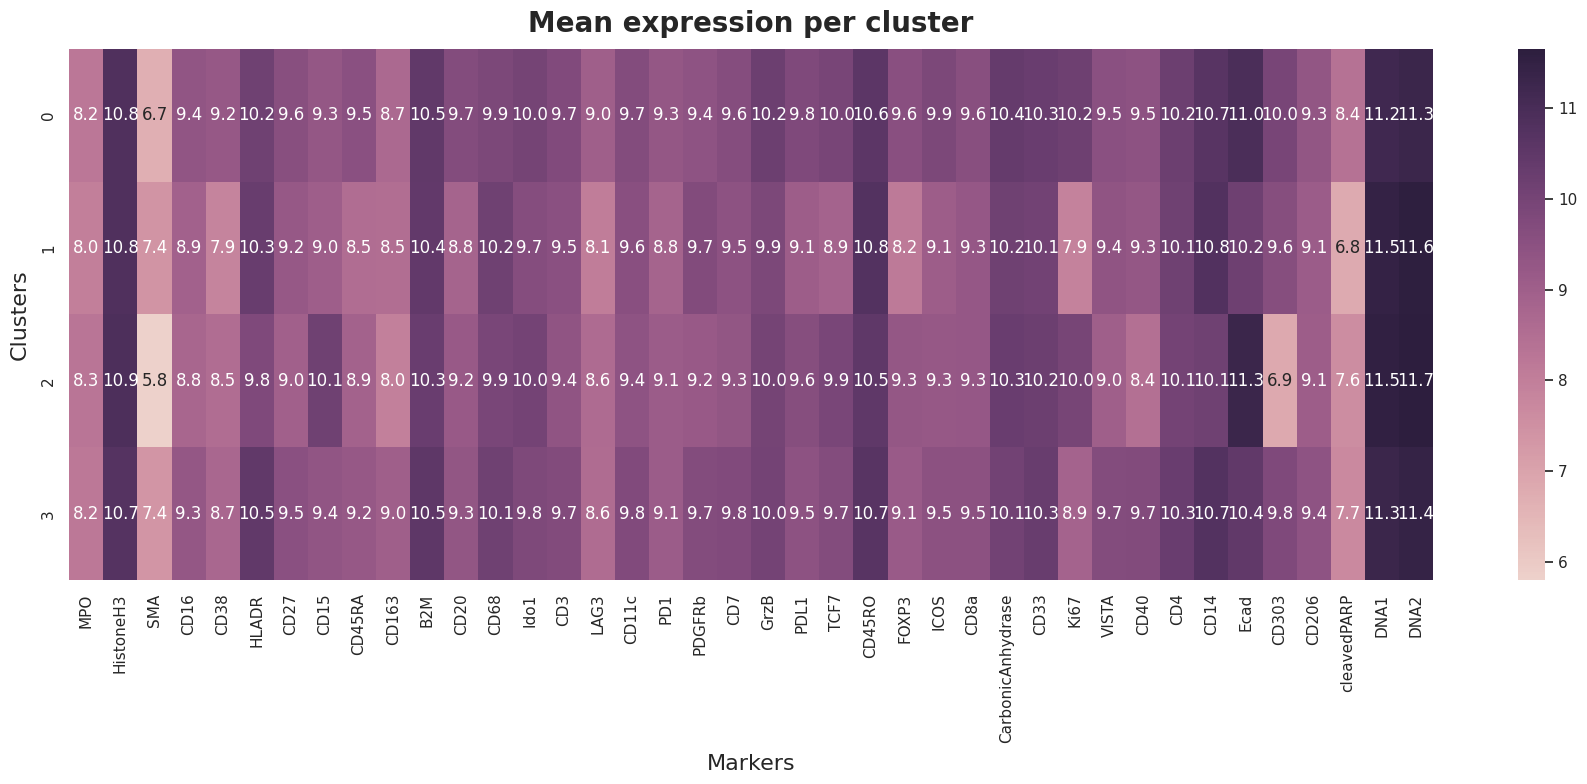

In [ ]:
# Mean marker analysis
clusters_exprs = []

for cluster in range(best_cluster):
    # For each cluster
    mask = train_anndata.obs['cluster_cellcharter'] == cluster
    cluster_data = train_anndata.layers['normalised_exprs'][mask, :]
    clusters_exprs.append(cluster_data.mean(axis=0))

# Make DataFrame to plot
expressions_clusters_df = pd.DataFrame(
    np.stack(clusters_exprs),
    columns=train_anndata.var['marker'],
    index=[f'{i}' for i in range(best_cluster)]
)

plot_heatmap(expressions_clusters_df, "Mean expression per cluster", ".1f", (18, 8), "Markers")

# scVI

In [ ]:
scvi.model.SCVI.setup_anndata(train_anndata,
                              layer="exprs",
                              batch_key="Batch"
)

model = scvi.model.SCVI(train_anndata,
                        n_latent=30,
                        gene_likelihood="nb"
)
model.train(max_epochs=200,
            accelerator=accelerator,
            early_stopping=True,
            enable_progress_bar=True
)

/usr/local/lib/python3.11/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[exprs] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Training:   0%|          | 0/200 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


In [ ]:
latent = model.get_latent_representation()
train_anndata.obsm["X_SCVI"] = latent

In [ ]:
cc.gr.aggregate_neighbors(
train_anndata,
n_layers=3,
use_rep='X_SCVI',
out_key='X_agg_SCVI',
sample_key='sample_id'
)

  0%|          | 0/132 [00:00<?, ?it/s]

In [ ]:
model_scvi = cc.tl.ClusterAutoK(n_clusters=n_clusters,
                                model_class=cc.tl.GaussianMixture,
                                model_params=model_params,
                                max_runs=16
)

train_anndata.obsm["X_agg_SCVI"] = train_anndata.obsm["X_agg_SCVI"].astype(np.float32)

model_scvi.fit(train_anndata[::10], use_rep='X_agg_SCVI')

Iteration 1/16


  0%|          | 0/30 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 2/16


  0%|          | 0/30 [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 10/16


  0%|          | 0/30 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Convergence with a change in stability of 0.007926330150513085 reached after 10 iterations


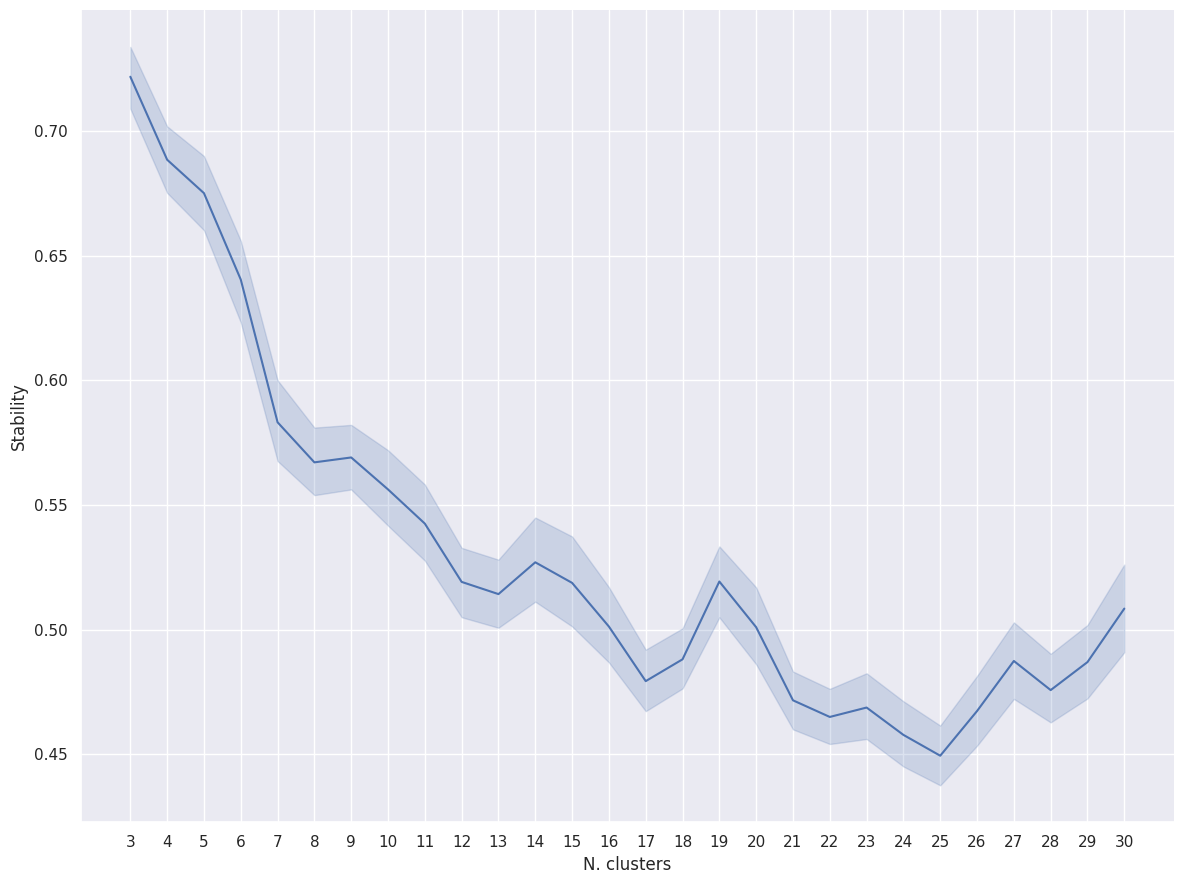

In [ ]:
cc.pl.autok_stability(model_scvi)
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
best_cluster = model_scvi.best_k
print(f"In SCVI case, {best_cluster} is the best candidate!")
train_anndata.obs['cluster_scvi'] = model_scvi.predict(train_anndata, use_rep='X_agg_SCVI', k=best_cluster)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In our case, 3 is the best candidate!


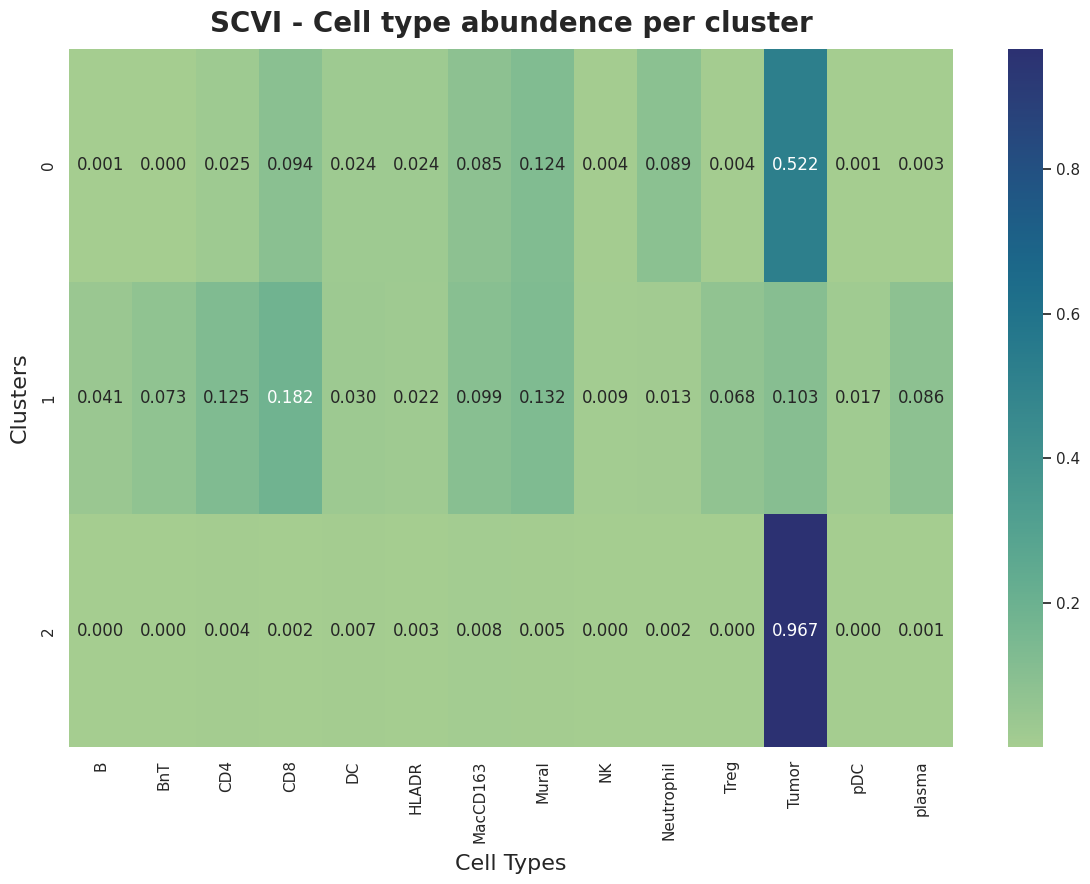

In [ ]:
# Cell type abundance SCVI
cell_type_abundance = train_anndata.obs.groupby('cluster_scvi', observed=True)['celltypes']\
                      .value_counts(normalize=True).unstack()
plot_heatmap(cell_type_abundance, "SCVI - Cell type abundence per cluster", ".3f")

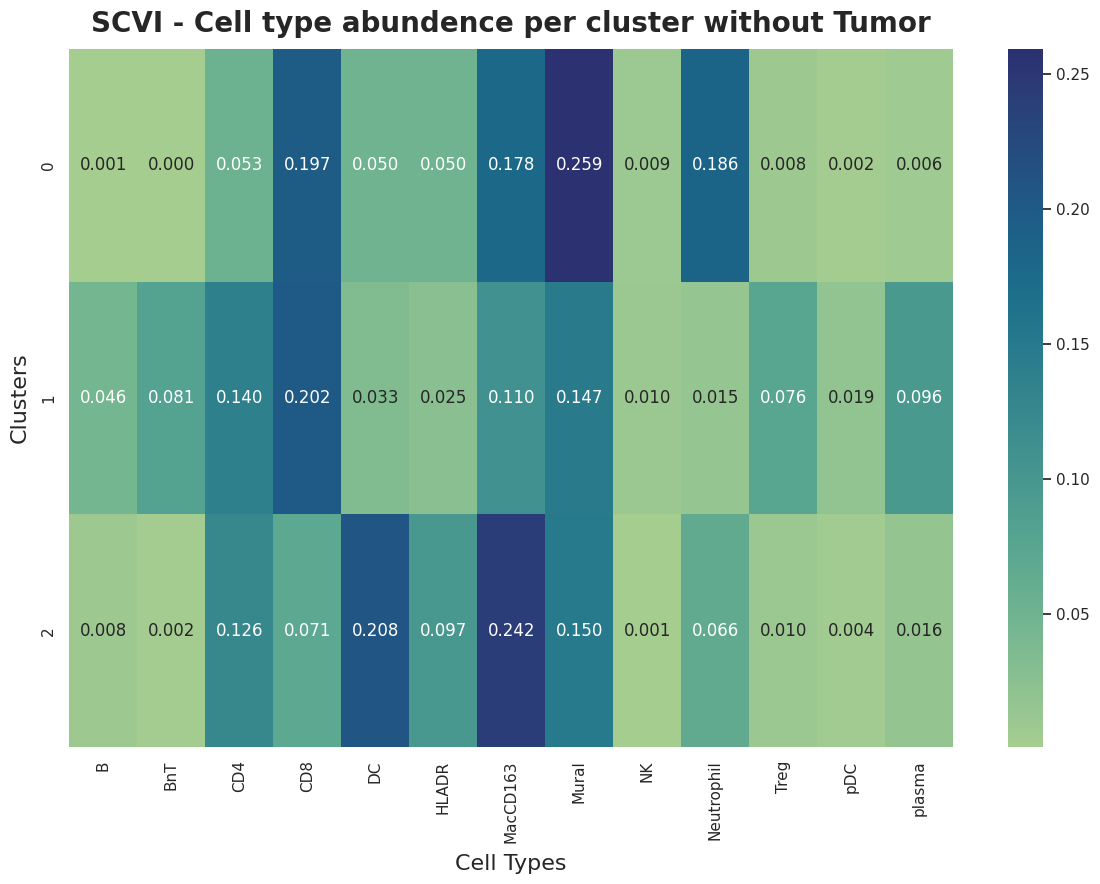

In [ ]:
# Cell type abundance without Tumor SCVI
cell_type_abundance = train_anndata.obs.groupby('cluster_scvi', observed=True)['celltypes']\
                      .value_counts().unstack()
cell_type_abundance.drop(columns=['Tumor'], inplace=True)
cell_type_abundance = cell_type_abundance.div(cell_type_abundance.sum(axis=1), axis=0)
plot_heatmap(cell_type_abundance, "SCVI - Cell type abundence per cluster without Tumor", ".3f")

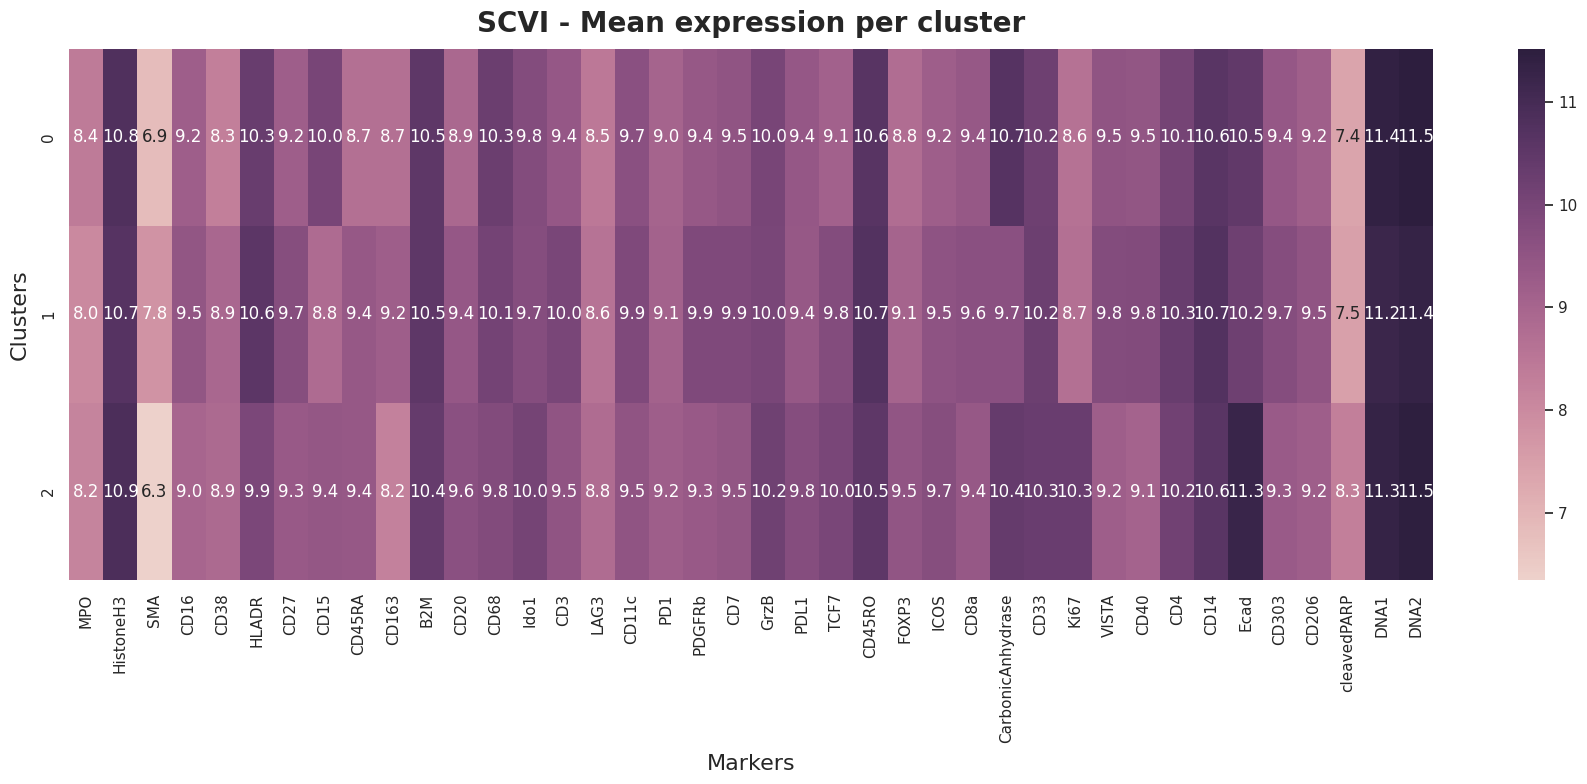

In [ ]:
# Mean marker analysis SCVI
clusters_exprs = []

for cluster in range(best_cluster):
    mask = train_anndata.obs['cluster_scvi'] == cluster
    cluster_data = train_anndata.layers['normalised_exprs'][mask, :]
    clusters_exprs.append(cluster_data.mean(axis=0))

expressions_clusters_df = pd.DataFrame(
    np.stack(clusters_exprs),
    columns=train_anndata.var['marker'],
    index=[f'{i}' for i in range(best_cluster)]
)

plot_heatmap(expressions_clusters_df, "SCVI - Mean expression per cluster", ".1f", (18, 8), "Markers")

In [11]:
# Clear cache
gc.collect()

15199

# PCA

In [14]:
model_pca = cc.tl.ClusterAutoK(n_clusters=n_clusters,
                                model_class=cc.tl.GaussianMixture,
                                model_params=model_params,
                                max_runs=16
)

train_anndata.obsm["X_PCA"] = train_anndata.obsm["X_PCA"].astype(np.float32)

model_pca.fit(train_anndata[::10], use_rep='X_PCA')

Iteration 1/16


  0%|          | 0/30 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 2/16


  0%|          | 0/30 [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 9/16


  0%|          | 0/30 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Convergence with a change in stability of 0.008127250603930948 reached after 9 iterations


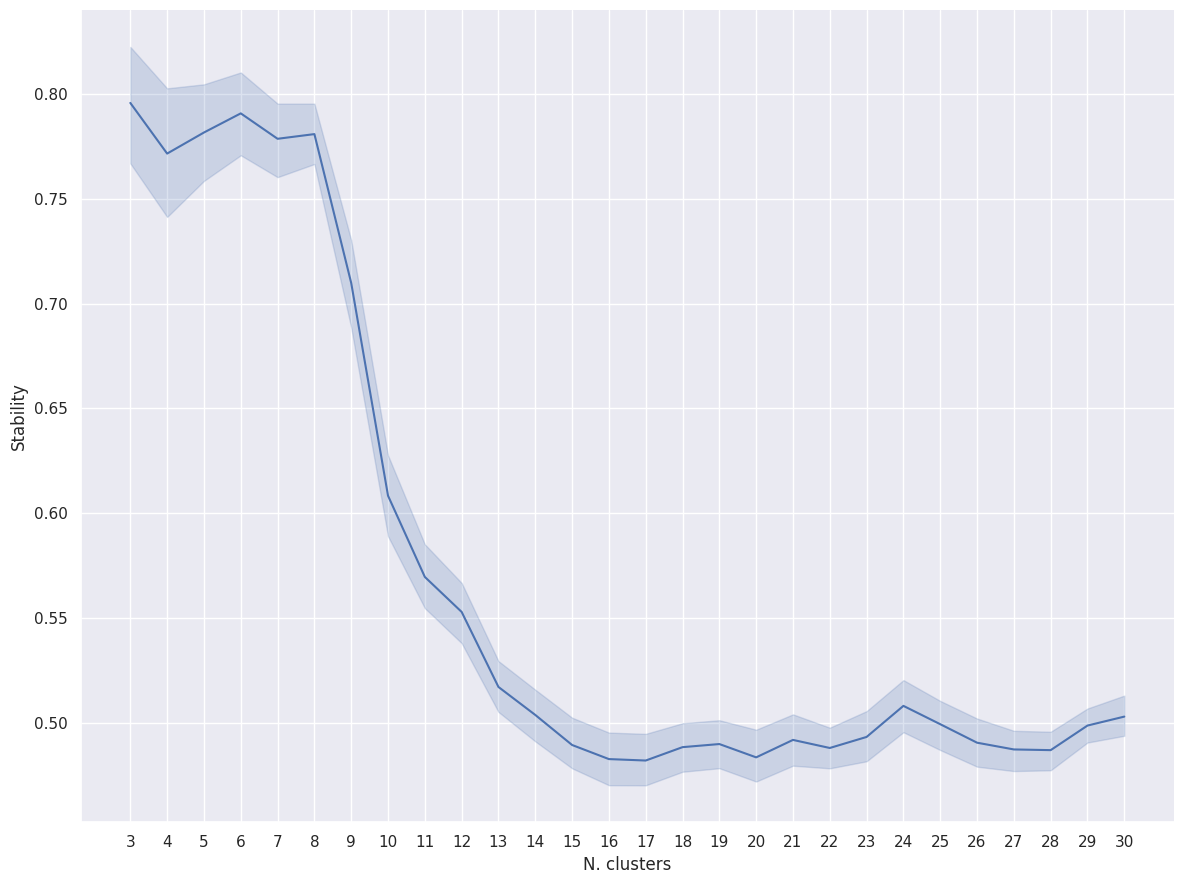

In [15]:
cc.pl.autok_stability(model_pca)
plt.tight_layout()
plt.show()
plt.close()

In [16]:
best_cluster = model_pca.best_k
print(f"In PCA case, {best_cluster} is the best candidate!")
train_anndata.obs['cluster_pca'] = model_pca.predict(train_anndata, use_rep='X_PCA', k=best_cluster)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In PCA case, 3 is the best candidate!


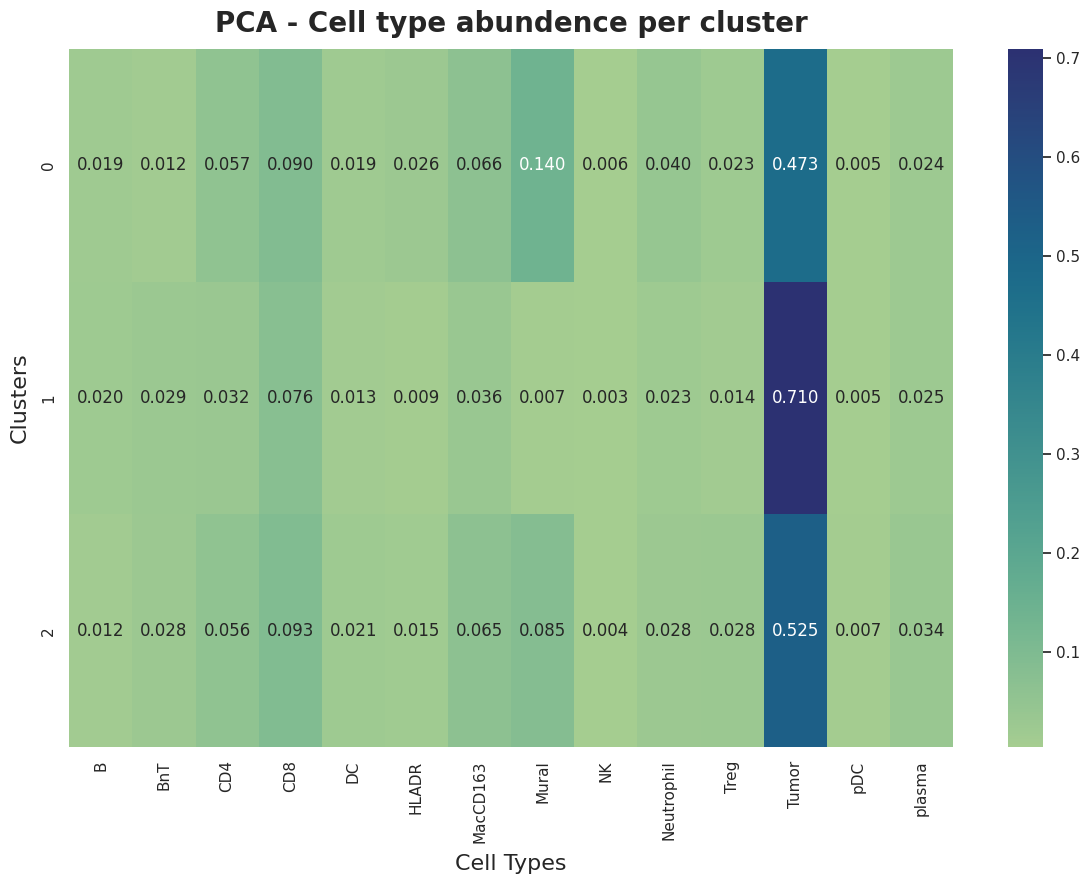

In [17]:
# Cell type abundance PCA
cell_type_abundance = train_anndata.obs.groupby('cluster_pca', observed=True)['celltypes']\
                      .value_counts(normalize=True).unstack()
plot_heatmap(cell_type_abundance, "PCA - Cell type abundence per cluster", ".3f")

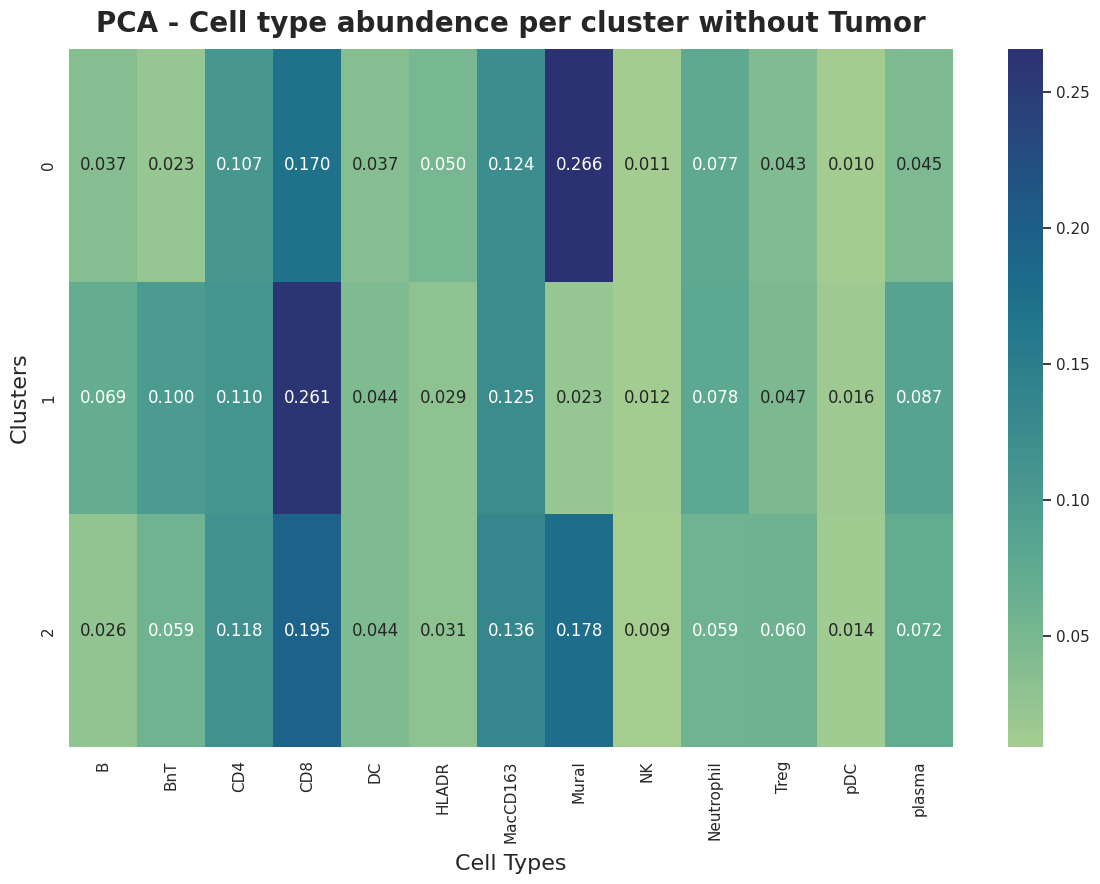

In [18]:
# Cell type abundance without Tumor PCA
cell_type_abundance = train_anndata.obs.groupby('cluster_pca', observed=True)['celltypes']\
                      .value_counts().unstack()
cell_type_abundance.drop(columns=['Tumor'], inplace=True)
cell_type_abundance = cell_type_abundance.div(cell_type_abundance.sum(axis=1), axis=0)
plot_heatmap(cell_type_abundance, "PCA - Cell type abundence per cluster without Tumor", ".3f")

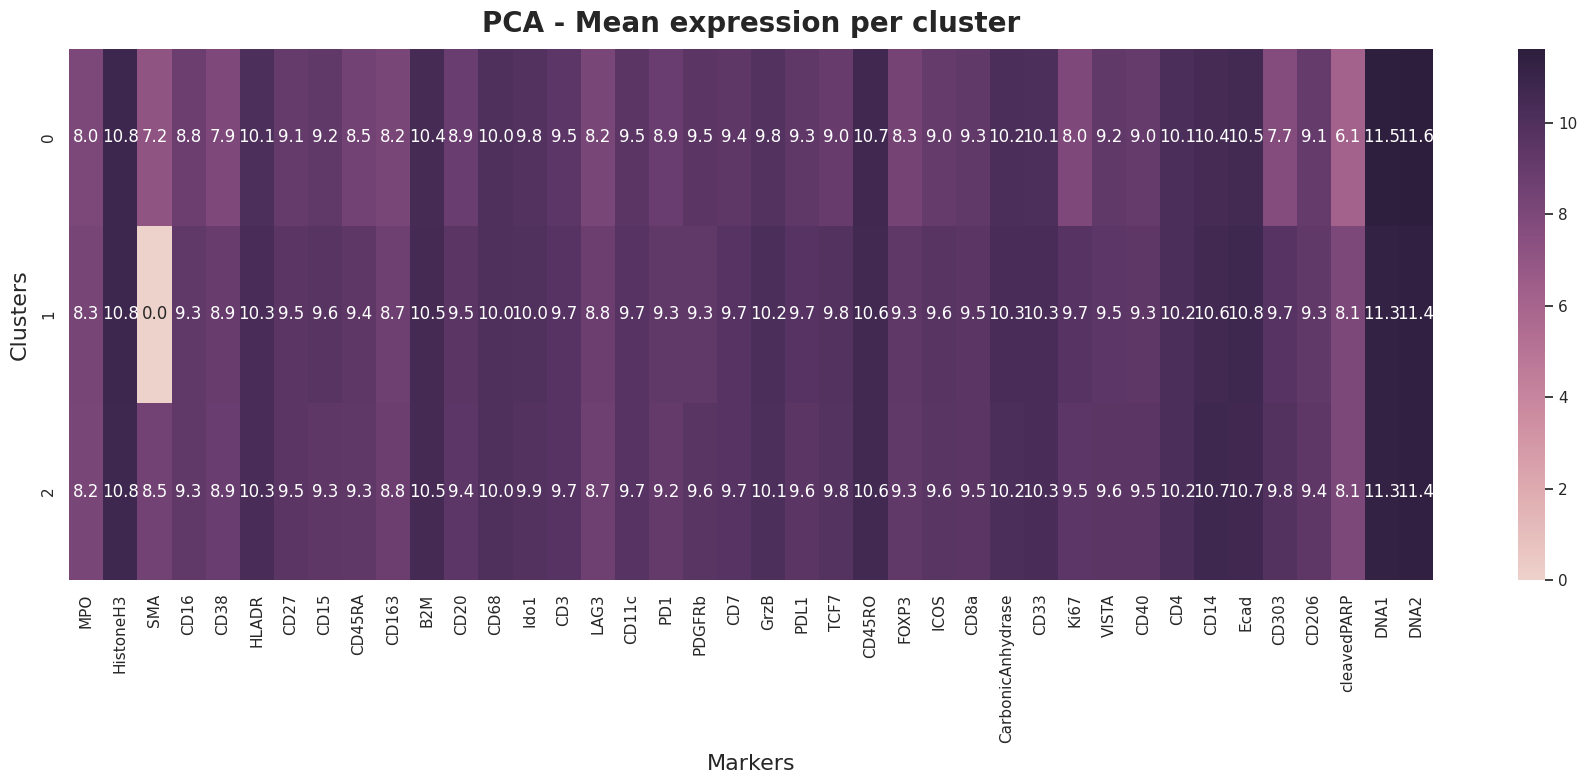

In [19]:
# Mean marker analysis PCA
clusters_exprs = []

for cluster in range(best_cluster):
    mask = train_anndata.obs['cluster_pca'] == cluster
    cluster_data = train_anndata.layers['normalised_exprs'][mask, :]
    clusters_exprs.append(cluster_data.mean(axis=0))

expressions_clusters_df = pd.DataFrame(
    np.stack(clusters_exprs),
    columns=train_anndata.var['marker'],
    index=[f'{i}' for i in range(best_cluster)]
)

plot_heatmap(expressions_clusters_df, "PCA - Mean expression per cluster", ".1f", (18, 8), "Markers")

# Comparison

In [ ]:
def make_cross_matrix(obs, col1, col2, normalize=True):
    """ Function returns a DataFrame with a
    cross-sectional matrix and percentages.
    """
    ct = pd.crosstab(obs[col1], obs[col2])
    if normalize:
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
        return ct, ct_pct

    return ct, None


def plot_cross_heatmap(ct_raw, ct_pct, title: str) -> None:
    """ Function plots a heatmap of a cross-count matrix.
    """
    plt.figure(figsize=plt.rcParams['figure.figsize'])
    ax = sns.heatmap(
        ct_raw,
        annot=False,
        fmt='d',
        cmap='YlOrBr',
        cbar_kws={'label': 'Number of Cells', 'pad': 0.05}
    )

    for i in range(ct_raw.shape[0]):
        for j in range(ct_raw.shape[1]):
            raw = ct_raw.iloc[i, j]
            pct = ct_pct.iloc[i, j]
            color = 'white' if raw >= 37000 else 'black'
            ax.text(
                j + 0.5, i + 0.4,
                f"{raw}",
                ha='center', va='center',
                color=color,
                fontsize=12, weight='bold'
            )
            ax.text(
                j + 0.5, i + 0.6,
                f"({pct:.1f}%)",
                ha='center', va='center',
                color=color,
                fontsize=8
            )

    ax.set_title(title, fontsize=16, pad=12, weight='bold')
    ax.set_xlabel(ct_raw.columns.name or '', fontsize=12)
    ax.set_ylabel(ct_raw.index.name or '', fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()

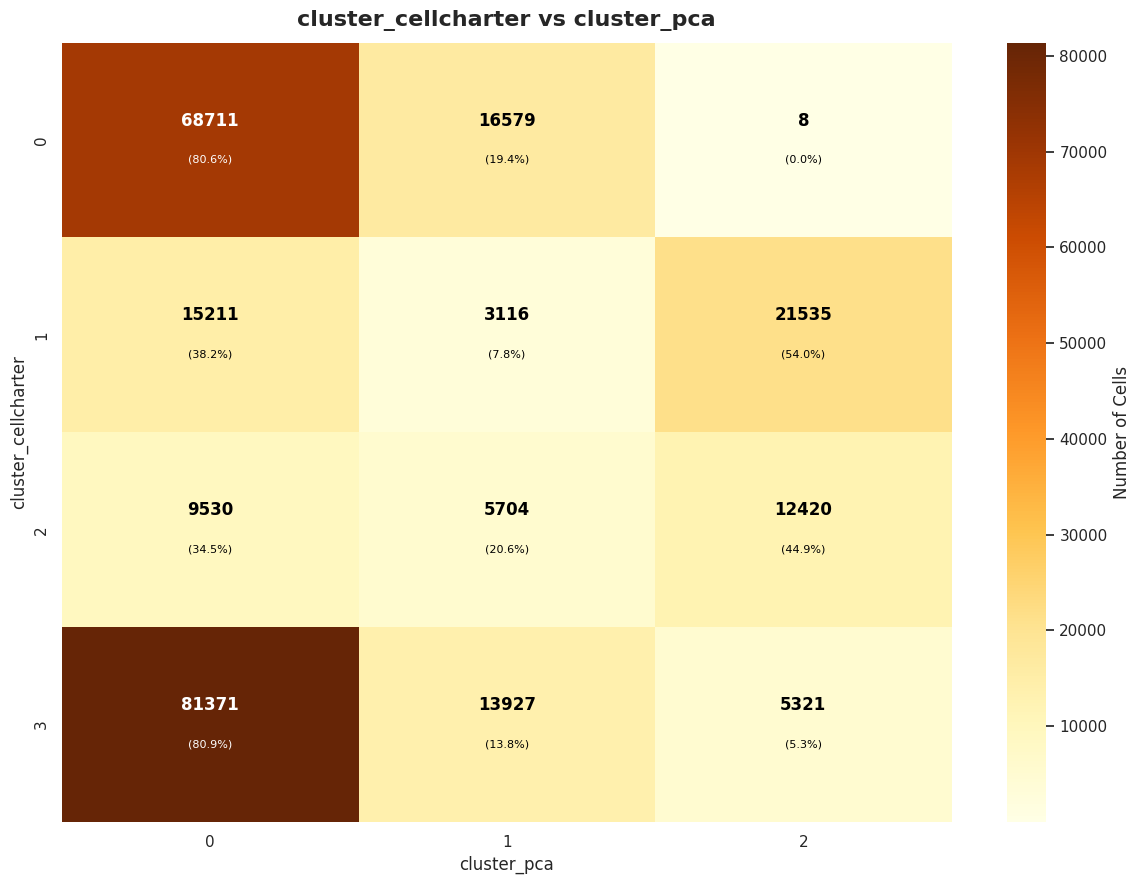

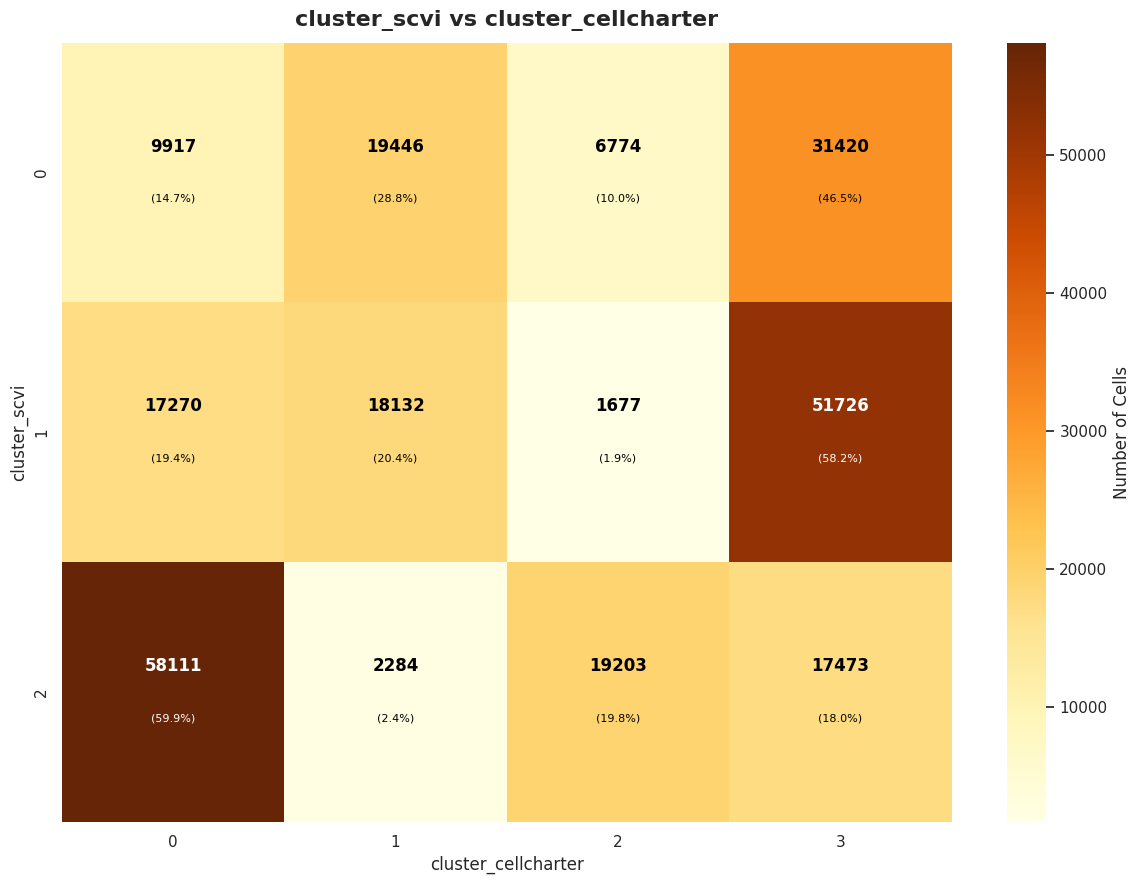

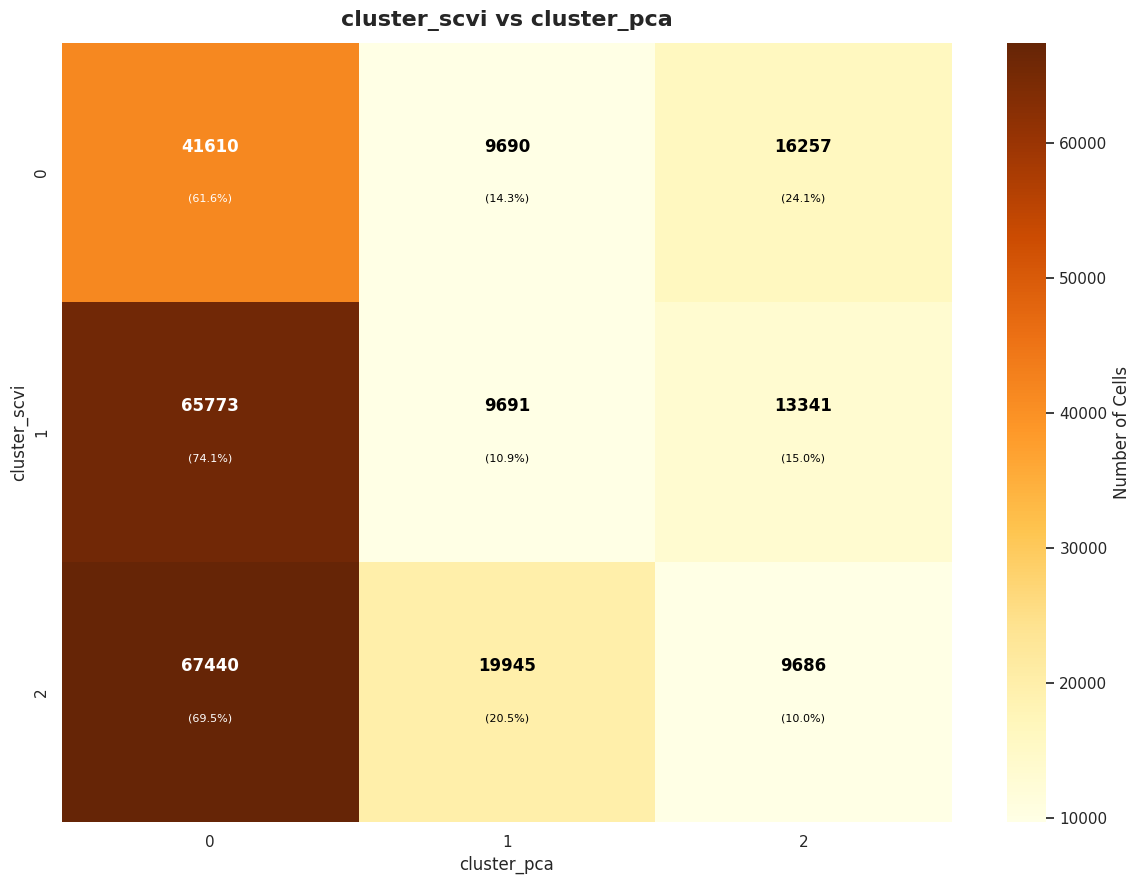

In [ ]:
for name_a, name_b in [('cluster_cellcharter','cluster_pca'), ('cluster_scvi','cluster_cellcharter'), ('cluster_scvi','cluster_pca')]:
    ct_left, ct_right = make_cross_matrix(train_anndata.obs, name_a, name_b)
    plot_cross_heatmap(ct_left, ct_right, f"{name_a} vs {name_b}")

# BERT-Charter

In [31]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.nn import TransformerEncoder, TransformerEncoderLayer
import torch.optim as optim

In [21]:
print(train_anndata)

AnnData object with n_obs × n_vars = 253433 × 40
    obs: 'image', 'sample_id', 'ObjectNumber', 'Pos_X', 'Pos_Y', 'area', 'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px', 'height_px', 'acquisition_id', 'SlideId', 'Study', 'Box.Description', 'Position', 'SampleId', 'Indication', 'BatchId', 'SubBatchId', 'ROI', 'ROIonSlide', 'includeImage', 'flag_no_cells', 'flag_no_ROI', 'flag_total_area', 'flag_percent_covered', 'small_cell', 'celltypes', 'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos', 'tumor_patches', 'distToCells', 'CD20_patches', 'Batch', 'cell_labels', 'classifier', 'cluster_pca'
    var: 'channel', 'use_channel', 'marker'
    uns: 'spatial_neighbors'
    obsm: 'X_PCA', 'spatial'
    layers: 'exprs', 'normalised_exprs'
    obsp: 'spatial_connectivities', 'spatial_distances'


In [24]:
class NeighborhoodDataset(Dataset):
    def __init__(self, adata, n_layers=3):
        self.adata = adata
        self.n_layers = n_layers
        self.adj_matrix = adata.obsp['spatial_connectivities'].tocsr()
        self.neighborhoods = []

        # Precompute neighborhoods using BFS
        for i in range(len(adata)):
            visited = set([i])
            layers = [[i]]
            current_layer = [i]

            for _ in range(n_layers-1):
                next_layer = []
                for node in current_layer:
                    neighbors = self.adj_matrix[node].indices
                    for nbr in neighbors:
                        if nbr not in visited:
                            visited.add(nbr)
                            next_layer.append(nbr)

                layers.append(next_layer)
                current_layer = next_layer

            self.neighborhoods.append(layers)

    def __len__(self):
        return len(self.adata)

    def __getitem__(self, idx):
        cells = []
        for layer_num, layer_cells in enumerate(self.neighborhoods[idx]):
            for cell in layer_cells:
                expr = self.adata.layers['exprs'][cell]
                cells.append((expr, layer_num + 1))
        return cells

In [27]:
class NeighborhoodEmbedder(nn.Module):
    def __init__(self, input_dim, embedding_dim):
        super().__init__()
        self.expr_embed = nn.Linear(input_dim, embedding_dim)
        self.layer_embed = nn.Embedding(10, embedding_dim)
        self.mask_vector = nn.Parameter(torch.randn(embedding_dim))

    def forward(self, expr, layers):
        expr_emb = self.expr_embed(expr)
        layer_emb = self.layer_embed(layers)
        mask = (layers == 0).unsqueeze(-1)
        return torch.where(mask, self.mask_vector, expr_emb + layer_emb)

In [30]:
class BERTCharter(nn.Module):
    def __init__(self, input_dim, embedding_dim=128):
        super().__init__()
        self.embedder = NeighborhoodEmbedder(input_dim, embedding_dim)
        encoder_layer = TransformerEncoderLayer(
            d_model=embedding_dim, nhead=4, dim_feedforward=512
        )
        self.encoder = TransformerEncoder(encoder_layer, num_layers=4)
        self.decoder = nn.Linear(embedding_dim, input_dim)

    def forward(self, expr, layers, padding_mask):
        embeddings = self.embedder(expr, layers)
        embeddings = embeddings.permute(1, 0, 2)
        output = self.encoder(embeddings, src_key_padding_mask=padding_mask)
        output = output.permute(1, 0, 2)
        return output, self.decoder(output)


In [32]:
def collate_fn(batch):
    max_len = max(len(seq) for seq in batch)
    expr_dim = batch[0][0][0].shape[0]

    padded_expr = torch.zeros((len(batch), max_len, expr_dim))
    padded_layers = torch.zeros((len(batch), max_len), dtype=torch.long)
    mask = torch.zeros((len(batch), max_len), dtype=torch.bool)

    for i, seq in enumerate(batch):
        for j, (e, l) in enumerate(seq):
            padded_expr[i,j] = torch.FloatTensor(e)
            padded_layers[i,j] = l
            mask[i,j] = True
    return padded_expr, padded_layers, mask

def train_model(adata, epochs=50):
    dataset = NeighborhoodDataset(adata)
    loader = DataLoader(dataset, batch_size=32, collate_fn=collate_fn)

    model = BERTCharter(adata.n_vars)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        total_loss = 0
        for expr, layers, mask in loader:
            # Maskowanie
            prob = torch.full_like(layers, 0.15, dtype=torch.float32)
            random_mask = torch.bernoulli(prob).bool() & mask
            masked_layers = layers.masked_fill(random_mask, 0)

            # Forward
            encoder_out, pred = model(expr, masked_layers, ~mask)

            # Obliczanie strat
            weights = torch.where(random_mask, 1.0, 0.1)
            loss = (weights[mask] * (pred[mask] - expr[mask])**2).mean()

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")
    return model

In [33]:
def get_embeddings(model, adata):
    dataset = NeighborhoodDataset(adata)
    loader = DataLoader(dataset, batch_size=32, collate_fn=collate_fn)

    embeddings = []
    with torch.no_grad():
        for expr, layers, mask in loader:
            encoder_out, _ = model(expr, layers, ~mask)
            embeddings.extend([x[m].mean(0).cpu().numpy() for x, m in zip(encoder_out, mask)])

    adata.obsm['X_bert'] = np.array(embeddings)

In [ ]:
model = train_model(train_anndata)